# Classification of Rice Varieties Using Ensemble Methods

## SPA6330 Final Project

Name: Haroon Parvez

Student ID: 220475901

Dataset: Rice Grain Classification (Cammeo and Osmancik)

## Problem Formulation

Automated rice classification is a real world agricultural sorting technique, its main advantage being to save time as manually sorting tons of rice is not practical. It is also useful for food quality control. The aim of this project is to classify rice grains as either Cammeo or Osmancik, these two types of rice have differences in quality and market value.

The problem that needs to be solved is to investigate whether the properties of the grains provide enough information to reliably distinguish between the two rice varieties. This is a supervised binary classification problem. This dataset is appropriate for this investigation as it contains numerical features describing the shape of individual rice grains that are important for differentiating between the two rice.

This is a suitable machine learning problem because the dataset is well organised and it is unreasonable for people to sort through thousands of tons of rice.

## Data Preparation and Feature Engineering

The dataset contains seven numerical input features and one target variable. The input features describe the size and shape of each rice grain.

- `Area`: the size of the rice grain
- `Perimeter`: the distance around the outer edge of the grain
- `Major_Axis_Length`: the length of the grain along its longest direction
- `Minor_Axis_Length`: the width of the grain along its shortest direction
- `Eccentricity`: a measure of how elongated the grain is
- `Convex_Area`: the area of the smallest convex shape that can contain the grain
- `Extent`: a measure of how much space the grain occupies within its bounding region

The target variable is `Class`, which identifies the rice variety as either Cammeo or Osmancik.

Now I will import the required modules and start pre-processing steps below:

- Summary statistics
- Data quality checks (e.g. missing values and class balance)
- Visualising outliers and comparing distributions
- Density plots to see class separation for each feature

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report

In [3]:
# load the dataset and look at the first few rows
df = pd.read_csv("rice_data.csv")
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [28]:
# Checking the shape of the data
print("Shape of dataset:", df.shape)

# Check columns and data info
print(df.columns)

print("\n")
df.info()

Shape of dataset: (3810, 8)
Index(['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent', 'Class'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(7), object(1)
memory usage: 238.3+ KB


In [29]:
# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

Missing values in each column:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64

Class distribution:
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


The dataset contains 3810 rows with 8 columns. There are no missing values in the dataset, so no imputation is required. The two classes are reasonably well balanced, although Osmancik appears more frequently than Cammeo.

In [30]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


The summary statistics show that the features `Area` and `Convex_Area` are in the tens of thousands, whereas `Eccentricity` and `Extent` take values below 1. As I will be using random forests later in this report, which split on feature values directly, standardisation will not be needed as it does not add benefit. The difference between minimum and max values looks normal.

The features also show different levels of spread such as `Area` and `Convex_Area` varying more widely than shape-based features such as `Eccentricity`. None of the summary statistics indicate impossible values. Looking at this information plus the ranges and quartiles, the dataset contains enough variation to make the classification meaningful.

Now to understand the distributions of the numerical features in more detail, I will use boxplots to compare their spread, central values, and possible outliers. This helps identify differences in scale between the variables and as well as extremely large or small values.

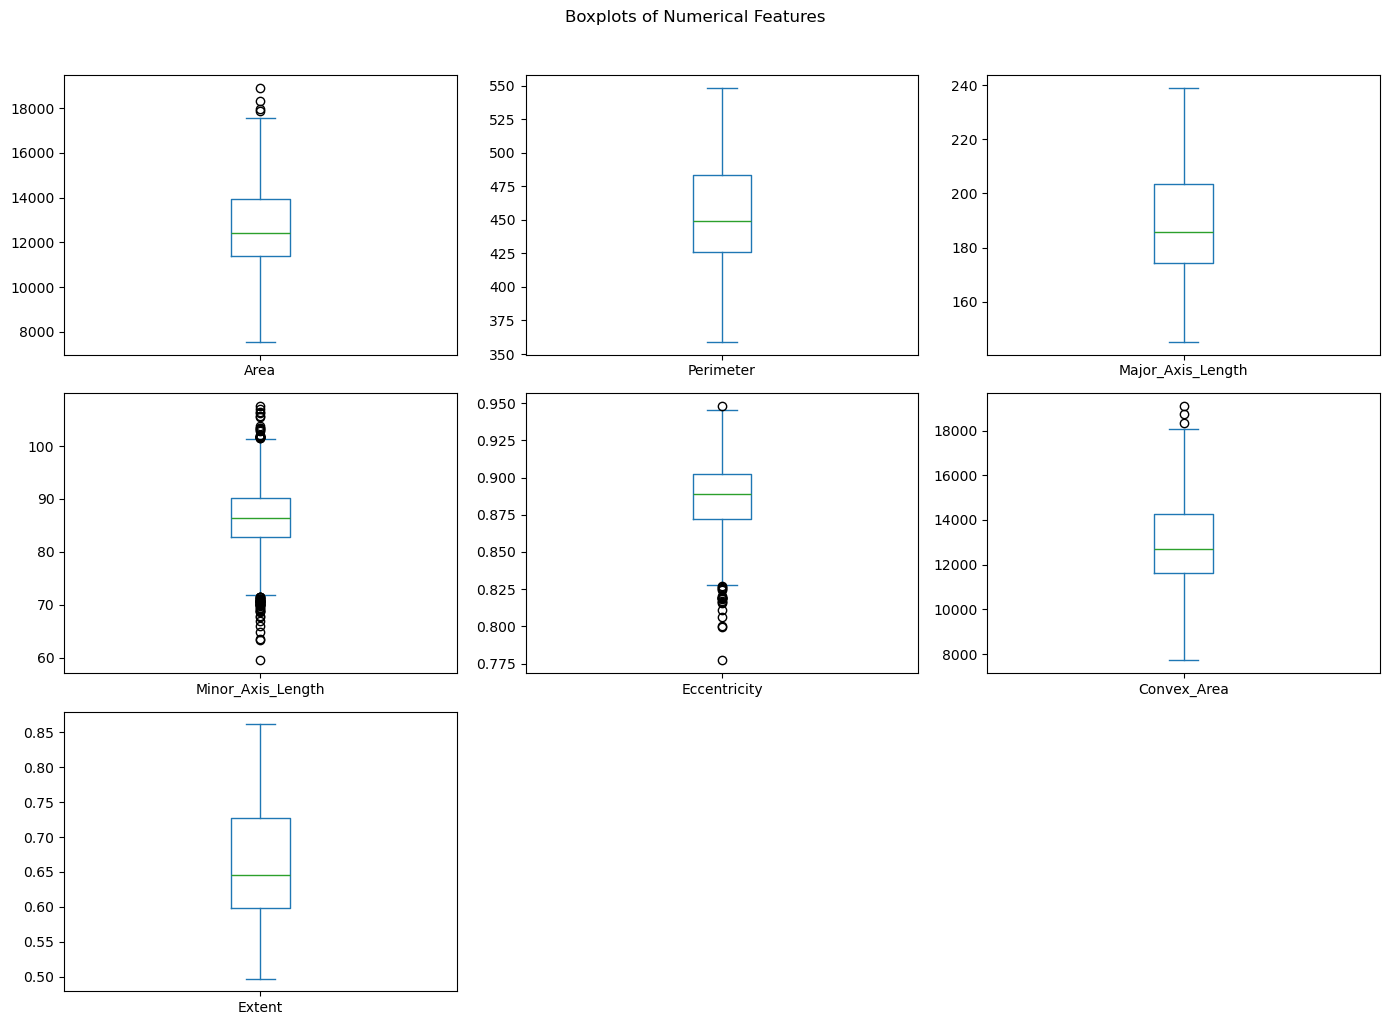

In [31]:
# Box plot plotting
feature_columns = ["Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
                   "Eccentricity", "Convex_Area", "Extent"]

df[feature_columns].plot(kind="box", subplots=True, layout=(3, 3), figsize=(14, 10), sharey=False)
plt.suptitle("Boxplots of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

`Area` and `Convex_Area` have the largest ranges. It is obvious that the size-related properties of the rice grains vary the most across the dataset. `Perimeter` and `Major_Axis_Length` also show noticeable variation.

Outliers can be seen in `Area`, `Convex_Area`, `Minor_Axis_Length`, and `Eccentricity`. These are not errors, since rice grains can and do vary in size. Removing them would be getting rid of genuine variation that likely helps in classifying between the two rice types. Decision Trees (which will be used later in this report) are robust to outliers, so there is no reason to drop them.

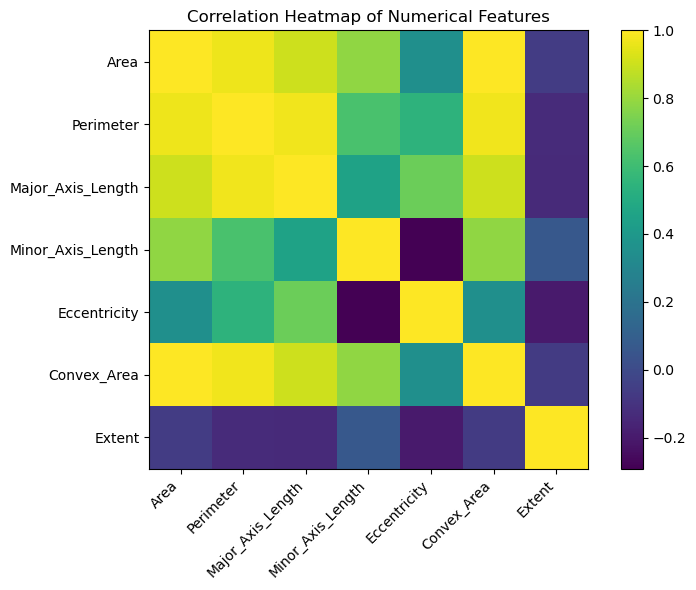

In [32]:
# Correlation Heatmap to see correlations between features
feature_columns = ["Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
                   "Eccentricity", "Convex_Area", "Extent"]

correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(feature_columns)), feature_columns, rotation=45, ha="right")
plt.yticks(range(len(feature_columns)), feature_columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

There are strong positive correlations for `Convex_Area` with `Area, Perimeter`, and `Major_Axis_Length`. I can understand this because they are essentially measuring the same thing but in diferent ways, `Minor_Axis_Length` is also positively correlated with these.

Eccentricity is positively correlated with `Major_Axis_Length` and negatively correlated with `Minor_Axis_Length`. Extent is only slightly correlated with the other variables and may provide some usable information that the size features do not really capture.

From the correlation heatmap, it is clear we can drop `Convex_Area` as a feature as it is too correlated and does not seem to bring anything unique to the classification.

To examine the shape of the feature distributions in more detail I will plot density plots, these plots would make it easier to compare how the values are distributed across features and to assess whether the two rice classes show visible differences in particular variables.

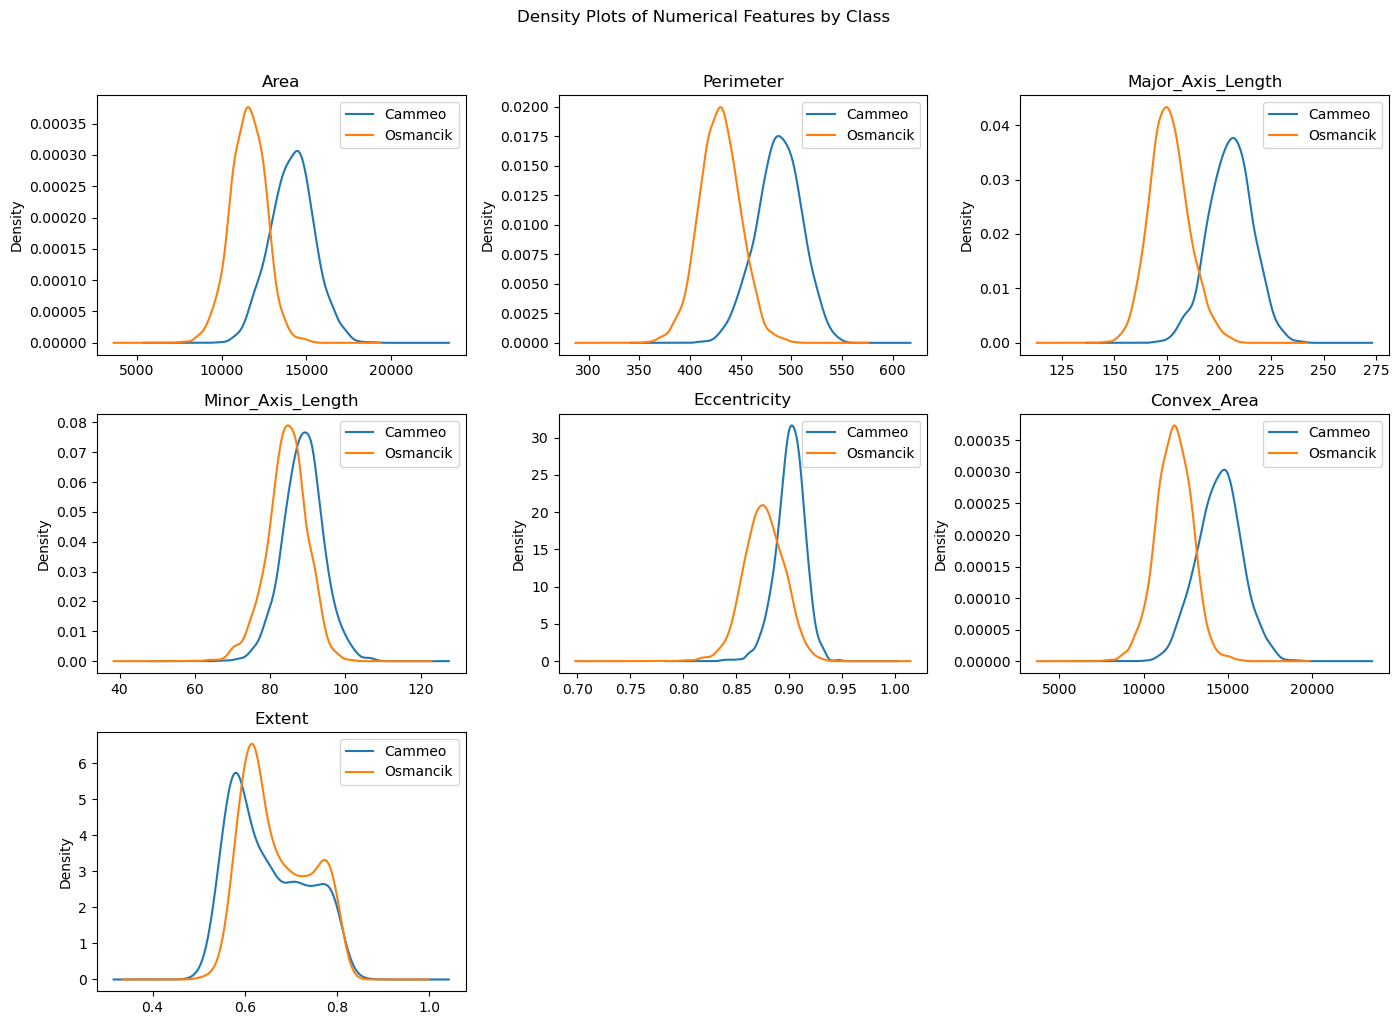

In [33]:
# Density plots plotting
feature_columns = ["Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
                   "Eccentricity", "Convex_Area", "Extent"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    df[df["Class"] == "Cammeo"][col].plot(kind="density", ax=axes[i], label="Cammeo")
    df[df["Class"] == "Osmancik"][col].plot(kind="density", ax=axes[i], label="Osmancik")
    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Density Plots of Numerical Features by Class", y=1.02)
plt.tight_layout()
plt.show()

`Area`, `Perimeter`, `Major_Axis_Length`, and `Convex_Area` show strong shifts between the Cammeo and Osmancik curves, with Cammeo taking larger values. These size-related features are most useful for classification.* There must be unique differences between the two rice grains when it comes to their sizes.

`Eccentricity` has a noticeable difference between the two classes, suggesting that the length of the grain may provide useful information not included in the size features. `Minor_Axis_Length` has more overlap than the previous features, although the two classes are still not close to identical like they are with `Extent`.

Based on the correlation heatmap and the density plots, I will now drop `Extent` and `Convex_Area` from the feature set. `Extent` showed the weakest separation between the two rice classes and appeared to contribute the least useful classification information. `Convex_Area` was almost perfectly correlated with other size-related features, especially `Area`. Thus keeping it would not add much benefit to the classification, as it does not provide new information. With these two features removed, I reduce overlap in the dataset while still keeping the main size and shape features needed for classification.

In [34]:
# Encode the class labels as numbers
label_encoder = LabelEncoder()
df["Class_encoded"] = label_encoder.fit_transform(df["Class"])

# Print the label mapping
print("Class labels:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

Class labels:
0 = Cammeo
1 = Osmancik


In [35]:
# Define the input features after removing Extent and Convex_Area
X = df[["Area", "Perimeter", "Major_Axis_Length",
        "Minor_Axis_Length", "Eccentricity"]]

# Define the target variable
y = df["Class_encoded"]

# Print the shapes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (3810, 5)
Shape of y: (3810,)


## Model Selection and Training



For this problem, I have chosen a **random forest classifier**. 

A random forest is an ensemble method that works by training many decision trees on different random bootstrap samples of the training data. Each tree makes its own classification, until eventually when making a final prediction, the predictions of all trees are collected and the final decision is the one receiving the most picks. 

A random forest was chosen because:

- They are more stable and less likely to overfit than a single decision tree.
- Extra randomness is introduced by considering only a random subset of features at each split, which increases diversity among the trees to improve generalisation
- Some of the input features are strongly correlated, and random forests can still perform well in this situation without requiring feature scaling.

This ensemble method is suitable for the rice dataset because several features show visible differences between the two rice classes, and the relationships between the grain properties and the target class may be not be linear.

Some disadvantages of this model are:

- Computationally more expensive than single decision trees
- It is harder to explain individual predictions than a single decision tree

The diagram below shows the basic structure of a random forest classifier:



```text
Training data
     │
     ▼
Random sampling of the data
     │
     ▼
 ┌─────────────┬─────────────┬─────────────┐
 ▼             ▼             ▼
Tree 1        Tree 2        Tree 3       ... more trees
 │             │             │
 ▼             ▼             ▼
Prediction    Prediction    Prediction
 └─────────────┴─────────────┴─────────────┘
                    │
                    ▼
             Majority vote
                    │
                    ▼
              Final class

The dataset is split into training and test sets, using 80% of the data for training and 20% for testing. Stratified splitting was used so that the class proportions were preserved in both sets. This makes the training and test data more representative of the full dataset.

In [36]:
# Split the data into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y)

# Print the shapes of the split datasets
print("Shape of Xtrain:", Xtrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of ytest:", ytest.shape)

Shape of Xtrain: (3048, 5)
Shape of Xtest: (762, 5)
Shape of ytrain: (3048,)
Shape of ytest: (762,)


In [37]:
# Create the random forest classifier with default parameters
model = RandomForestClassifier(random_state=3)

# Train the model
model.fit(Xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Plotting one of the decision trees below:

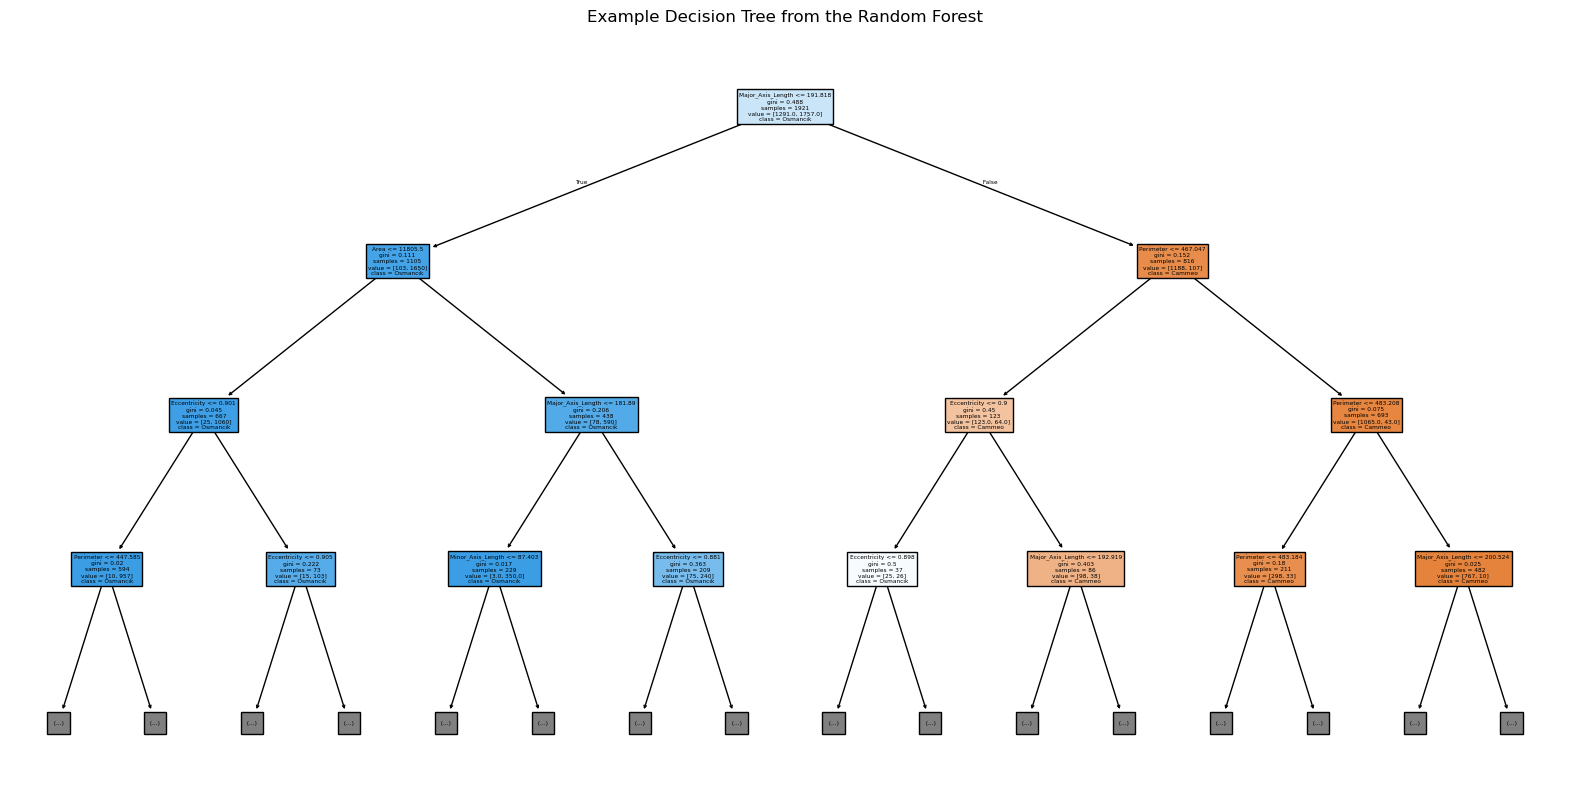

In [38]:
# Plot one tree from the fitted random forest
plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    max_depth=3
)
plt.title("Example Decision Tree from the Random Forest")
plt.show()

The figure above shows one example decision tree from the random forest ensemble.

In [39]:
# Predict the class labels for the training and test sets
ytrain_pred = model.predict(Xtrain)
ytest_pred = model.predict(Xtest)

# Print the training and test accuracy scores
print("Training accuracy:", accuracy_score(ytrain, ytrain_pred))
print("Test accuracy:", accuracy_score(ytest, ytest_pred))

Training accuracy: 1.0
Test accuracy: 0.9133858267716536


The training accuracy is almost perfect, while test set accuracy is also quite high.

I will also find the precision and recall metrics as they give more detail about the models classification ability.

In [40]:
# Predict the class labels for the training and test sets
ytrain_pred = model.predict(Xtrain)
ytest_pred = model.predict(Xtest)

# Print training metrics
print("TRAINING SET METRICS")
print("Accuracy:  {:.3f}".format(accuracy_score(ytrain, ytrain_pred)))
print("Precision: {:3f}".format(metrics.precision_score(ytrain, ytrain_pred)))
print("Recall:    {:.3f}".format(metrics.recall_score(ytrain, ytrain_pred)))

# Print test metrics
print()
print("TEST SET METRICS")
print("Accuracy:  {:.3f}".format(accuracy_score(ytest, ytest_pred)))
print("Precision: {:.3f}".format(metrics.precision_score(ytest, ytest_pred)))
print("Recall:    {:.3f}".format(metrics.recall_score(ytest, ytest_pred)))

TRAINING SET METRICS
Accuracy:  1.000
Precision: 1.000000
Recall:    1.000

TEST SET METRICS
Accuracy:  0.913
Precision: 0.919
Recall:    0.931


The training set metrics show that the data has completely memorised the training set.

A precision of about 0.919 means that when the model predicts the positive class, it is correct most of the time. A recall of 0.931 means that the model successfully identifies most of the true positive cases.

The recall is slightly higher than the precision so the model is slightly better at positive predictions than avoiding false positives.

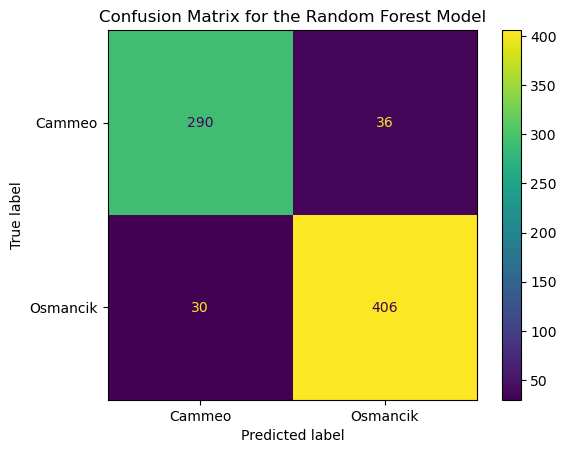

True negatives: 290
False positives: 36
False negatives: 30
True positives: 406


In [41]:
# Calculate the confusion matrix
cm = metrics.confusion_matrix(ytest, ytest_pred, labels=model.classes_)

# Display the confusion matrix
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix for the Random Forest Model")
plt.show()

# Print the values
print("True negatives:", cm[0, 0])
print("False positives:", cm[0, 1])
print("False negatives:", cm[1, 0])
print("True positives:", cm[1, 1])

The confusion matrix showed that the random forest model classifies most test samples correctly, but makes 36 false positive predictions and 30 false negative predictions. This makes sense with the earlier metric scores, which already showcased strong test performance. We can already conclude that overfitting is an issue at the moment.

## Model Evaluation

The assessments in the previous section gave an initial look at forests performance, but more detailed evaluation will be needed to assess how well the random forest classifier generalises and why incorrect classifications are happening.

I will use an ROC curve to assess how well the model separates the two classes across different classification thresholds. This provides another view of performance than accuracy, since it shows the trade off between the true positive rate and the false positive rate.

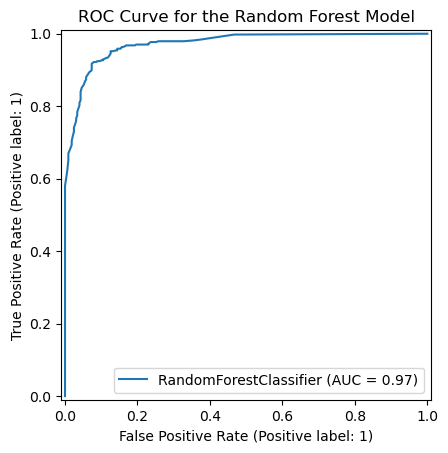

In [42]:
# ROC curve
metrics.RocCurveDisplay.from_estimator(model, Xtest, ytest)
plt.title("ROC Curve for the Random Forest Model")
plt.show()

The ROC curve rises rapidly, and the area under the curve is 0.97, which represents very strong classification performance. Since an AUC value closer to 1 indicates better class separation.

To evaluate the model more reliably, I will use **stratified k-fold cross-validation**. This method splits the dataset into 5 folds while preserving the class balance in each fold. If we don't preserve class balance, the results will simply not be reliable.

In [43]:
# Define the cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

# Define the metrics
scoring = ["accuracy", "precision", "recall"]

# Calculate train and test scores
scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print accuracy scores
print("Train accuracy: {:.3f} +/- {:.3f}".format(scores["train_accuracy"].mean(), scores["train_accuracy"].std()))
print("Test accuracy: {:.3f} +/- {:.3f}".format(scores["test_accuracy"].mean(), scores["test_accuracy"].std()))
print()
# Print precision scores
print("Train precision: {:.3f} +/- {:.3f}".format(scores["train_precision"].mean(), scores["train_precision"].std()))
print("Test precision: {:.3f} +/- {:.3f}".format(scores["test_precision"].mean(), scores["test_precision"].std()))
print()
# Print recall scores
print("Train recall: {:.3f} +/- {:.3f}".format(scores["train_recall"].mean(), scores["train_recall"].std()))
print("Test recall: {:.3f} +/- {:.3f}".format(scores["test_recall"].mean(), scores["test_recall"].std()))

Train accuracy: 1.000 +/- 0.000
Test accuracy: 0.920 +/- 0.007

Train precision: 1.000 +/- 0.000
Test precision: 0.929 +/- 0.005

Train recall: 1.000 +/- 0.000
Test recall: 0.931 +/- 0.010


Default hyperparameters for the random forest uses unrestricted tree depth which explains the high train score. This shows the need for hyperparameter tuning.

At the same time, the test score remains high and the standard deviation is low, which shows that the model is still performing well and consistently across different folds.

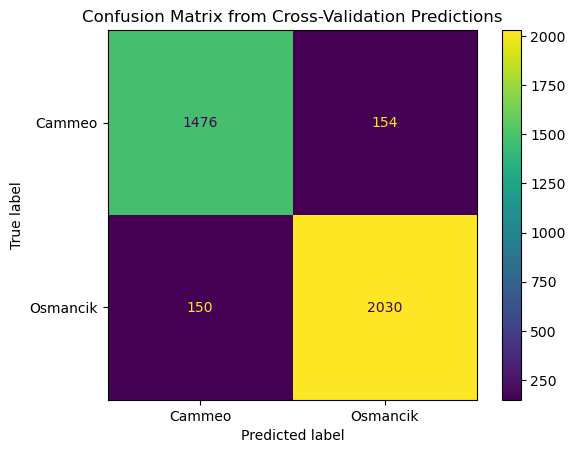

True negatives: 1476
False positives: 154
False negatives: 150
True positives: 2030


In [44]:
# Generate cross-validation predictions
y_pred_cv = cross_val_predict(model, X, y, cv=cv)

# Calculate the confusion matrix
cm_cv = confusion_matrix(y, y_pred_cv)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix from Cross-Validation Predictions")
plt.show()

# Print the values
print("True negatives:", cm_cv[0, 0])
print("False positives:", cm_cv[0, 1])
print("False negatives:", cm_cv[1, 0])
print("True positives:", cm_cv[1, 1])

The confusion matrix tells us that the model performs well and correctly identifies most of the rice grains, but makes a noticeable amount of errors due to the training set being memorised too well. 

## Model Tuning

The previous results showed that the random forest model achieved strong performance, but the gap between training and test accuracy showed that some overfitting is present. As mentioned in the previous section, the default random forest has an unrestricted tree depth, causing the overfitting. There are other hyperparameters as well which are probably not optimal. Now in this section I will investigate this.

Learning curves will be used with **accuracy** as the scoring metric. This is appropriate as we have 2 target variables.

In [ ]:
# Calculate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=3
)

# Calculate the mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
plt.plot(train_sizes, test_mean, marker="o", label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for the Random Forest Model")
plt.legend()
plt.show()

This is not a good model. The training accuracy is stuck at 1 and the validation accuracy jumps at random. Mow I can try to improve this by using GridSearchCV to look for the optimal hyperparameters. It will test out combinations of given hyperparameters for the best performing model.

In [ ]:
# Define the hyperparameter options
parameters = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Run the grid search
model = GridSearchCV(
    RandomForestClassifier(random_state=3),
    parameters,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=3),
    verbose=1,
    n_jobs=4,
    return_train_score=True)

model.fit(Xtrain, ytrain)

print("Best params, best score:", "{:.4f}".format(model.best_score_), model.best_params_)

The grid search found the best performing model to have a cross-validation score of 0.9288, slightly higher than the performance of the default model (0.920). We can immediately see that limiting the tree depth and requiring slightly larger splits and leaf sizes improved generalisation. The tuned model should now provide a better balance between fitting the training data.

In [ ]:
# Calculate the learning curve for the tuned model
train_sizes, train_scores, validation_scores = learning_curve(
    model.best_estimator_,
    Xtrain,
    ytrain,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.3, 1.0, 8),
    n_jobs=4
)

# Calculate the mean scores
train_scores_mean = train_scores.mean(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, "o-", label="Training accuracy")
plt.plot(train_sizes, validation_scores_mean, "o-", label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for the Tuned Random Forest Model")
plt.legend()
plt.show()

The learning curve for the tuned random forest model is a big improvement, it remains stable as the training set size increases. The training accuracy looks normal now fluctuating around 0.945, while the validation accuracy stays close to about 0.926. The tuned model performs well and is does not have severe overfitting anymore. The accuracy remaining stable for the larger training sizes means that the model performance is consistent as more data is used.

# Model Tuning Results

In [ ]:
# Predicting the test labels using the tuned model
ytestpred_tuned = model.predict(Xtest)

# Default and tuned model metrics
print("Default test accuracy:", metrics.accuracy_score(ytest, ytest_pred))
print("Tuned test accuracy:", metrics.accuracy_score(ytest, ytestpred_tuned))

print("\nDefault precision:", metrics.precision_score(ytest, ytest_pred))
print("Tuned precision:", metrics.precision_score(ytest, ytestpred_tuned))

print("\nDefault recall:", metrics.recall_score(ytest, ytest_pred))
print("Tuned recall:", metrics.recall_score(ytest, ytestpred_tuned))

The tuned model shows a small improvement in overall test accuracy and a large improvement in Recall from about 0.931 to 0.945, which means the tuned model is better at correctly identifying Osmancik grains.

Precision decreases slightly, so the tuned model makes a few more false positive Osmancik predictions than the default model. However, this change is small and the tuned model provides a better balance between generalisation and classification performance, therefore I can confidently confirm that the tuned model can be considered the stronger final model.

## Conclusion

The analysis concluded that several features in the dataset related to size were strong in differentiating between both classes. These include `Area`, `Perimeter`, `Major_Axis_Length`, and `Convex_Area`. Other shape related features were also able to provide some useful information.

The random forest showed that it was more robust than a single decision tree. With strong test accuracy and high precision and recall scores. Thus this ensemble method proved to perform well in classifying between the rice grains.

The main issue I ran into was overfitting. The default parameters for the random forest ensemble caused the model to memorise the training data perfectly, resulting in maximum scores (of 1.0) for all train scores.. Hyperparameter tuning using grid search gave a noticeable improvement in test accuracy and recall. The comparison of learning curves before and after tuning also demonstrated reduced overfitting and improved the balance between the fitting the training data while also maintaining strong validation performance.

Overall, the results suggest that ensemble tree-based methods are well suited to the rice dataset and can classify the two rice varieties successfully using the dataset features.

However there are several ways in which the project could be improved. 

- A wider comparison with other classification models, such as support vector machines or gradient boosting methods, could show whether random forest is truly the strongest choice.

- Further tuning with a larger hyperparameter search may also lead to additional improvements.

- Feature selection could be explored more to determine whether similar performance can be achieved with fewer input variables.